# Ethical AI - Bias analysis with AI Fairness 360

**Goal:** Detect and reduce bias in the HR turnover model across the sensitive attribute :

**Attribute:**

- Age → colonne Age : groupes under 45 vs over 45

The 45 year threshold was chosen based on our data exploration : employees aged 45 and over show a consistently higher turnover rate than younger employees, making this a meaningful split for bias detection.

**Method:** For each attribute:
1. Measure bias in the data (Disparate Impact + SPD)
2. Measure bias in the model predictions (EOD + AOD)
3. Apply Reweighing mitigation
4. Compare before / after

## About the sensitive attributes of the dataset

Under European law (GDPR Article 9 + EU AI Act), processing special categories of personal data (including gender, racial or ethnic origin) for automated decision-making in employment contexts is prohibited.

So, these columns have been:
- Removed from the model and not used as features
- Excluded from the bias audit

The only sensitive attribute we audit is Age which is permitted under European HR analytics frameworks and relevant given the observed turnover gap between employees over and under 45 in our dataset.

## 0. Imports

In [3]:
%pip install aif360


  Using cached aif360-0.6.1-py3-none-any.whl.metadata (5.0 kB)
Using cached aif360-0.6.1-py3-none-any.whl (259 kB)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# AI Fairness 360 

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing


## 1. Load data 

In [35]:
df = pd.read_csv('hr_cleaned.csv')

print(f'Shape: {df.shape}')
print(f'Turnover rate: {df["Termd"].mean():.0%} ({df["Termd"].sum()} / {len(df)} employees)\n')

# transform Age as a binary column : 0 = under 45 (younger), 1 = 45 and over (older) (older workers can face age discrimination)
df['AgeGroup'] = (df['Age'] >= 45).astype(int)  

# Summary of sensitive groups
print('Sensitive attribute distributions :')
print(f'Age - Under 45: {(df["AgeGroup"]==0).sum()} ({df[df["AgeGroup"]==0]["Termd"].mean():.0%} turnover)  |  over 45: {(df["AgeGroup"]==1).sum()} ({df[df["AgeGroup"]==1]["Termd"].mean():.0%} turnover)')

Shape: (311, 32)
Turnover rate: 33% (104 / 311 employees)

Sensitive attribute distributions :
Age - Under 45: 155 (32% turnover)  |  over 45: 156 (35% turnover)


In [36]:
df['ManagerID'] = df['ManagerID'].fillna(-1)

## 2. Train baseline model

In [37]:
target = 'Termd'

sensitive_cols = ['AgeGroup']

features = [c for c in df.columns if c not in [target,'AgeGroup']]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Random Forest with balanced class weights (dataset is 67% active / 33% terminated)
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(' Baseline model results :\n')
print(classification_report(y_test, y_pred, target_names=['Active', 'Terminated']))

 Baseline model results :

              precision    recall  f1-score   support

      Active       0.74      0.94      0.83        52
  Terminated       0.75      0.35      0.47        26

    accuracy                           0.74        78
   macro avg       0.75      0.64      0.65        78
weighted avg       0.74      0.74      0.71        78



## 3. Functions

We define reusable functions so we can run the same fairness audit for each sensitive attribute

In [38]:
def make_aif_dataset(X_part, y_part, sensitive_col, df_full):
    """
    Converts a pandas dataframe into a BinaryLabelDataset that can be used with aif360
    """
    df_part = X_part.copy()
    df_part[target] = y_part.values 
    # Add the sensitive column if it's not already in X
    if sensitive_col not in df_part.columns:
        df_part[sensitive_col] = df_full.loc[X_part.index, sensitive_col].values
    return BinaryLabelDataset( # the label is binary
        df=df_part,
        label_names=[target],
        protected_attribute_names=[sensitive_col],
        favorable_label=0, # good for the employee
        unfavorable_label=1) # bad for the employee : raise awareness to see if these people are more likely to be terminated


def run_fairness_audit(sensitive_col, privileged_val, unprivileged_val,
                       priv_label, unpriv_label):
    """
    fairness pipeline for one sensitive attribute:
    """
    privileged = [{sensitive_col: privileged_val}]
    unprivileged = [{sensitive_col: unprivileged_val}]

    # Build aif360 datasets
    aif_train = make_aif_dataset(X_train, y_train, sensitive_col, df)
    aif_test= make_aif_dataset(X_test,  y_test,  sensitive_col, df)

    # measure bias in the training data (before any model)
    m_before = BinaryLabelDatasetMetric(aif_train,
                   privileged_groups=privileged, unprivileged_groups=unprivileged)
    di_before = m_before.disparate_impact() # ratio of favorable outcomes (not terminated) for unprivileged vs privileged groups ( 1 means fair)
    spd_before = m_before.statistical_parity_difference() # measures the difference in favorable outcome rates between unprivileged and privileged groups (0 means fair)

    # Measure bias in the baseline model
    aif_pred_before = aif_test.copy()
    aif_pred_before.labels = y_pred.reshape(-1, 1)
    cm_before = ClassificationMetric(aif_test, aif_pred_before,
                    privileged_groups=privileged, unprivileged_groups=unprivileged) # compares the true labels (aif_test) and the predicted labels (aif_pred_before)
    # across the two groups
    eod_before = cm_before.equal_opportunity_difference() # difference in true positive rates between unprivileged and privileged groups (0 means fair)
    aod_before = cm_before.average_odds_difference() #average difference in false positive and true positive rates between groups (0 means fair)

    # Reweighing : adjust the weights of the training examples to balance the representation of privileged and unprivileged groups
    rw = Reweighing(unprivileged_groups=unprivileged, privileged_groups=privileged)
    aif_train_rw = rw.fit_transform(aif_train)

    # measure bias in the training data after reweighing
    m_after = BinaryLabelDatasetMetric(aif_train_rw,
                  privileged_groups=privileged, unprivileged_groups=unprivileged)
    di_after  = m_after.disparate_impact()
    spd_after = m_after.statistical_parity_difference()

    # Retrain the  model with the corrected weights
    model_fair = RandomForestClassifier(n_estimators=100, random_state=42,
                                        class_weight='balanced')
    model_fair.fit(X_train, y_train, sample_weight=aif_train_rw.instance_weights)
    y_pred_fair = model_fair.predict(X_test)

    # prediction (fair model)
    aif_pred_after = aif_test.copy()
    aif_pred_after.labels = y_pred_fair.reshape(-1, 1)
    cm_after = ClassificationMetric(aif_test, aif_pred_after,
                   privileged_groups=privileged, unprivileged_groups=unprivileged)
    eod_after = cm_after.equal_opportunity_difference()
    aod_after = cm_after.average_odds_difference()

    return {
        'protected_col': sensitive_col,
        'priv_label': priv_label,
        'unpriv_label': unpriv_label,
        'di_before': di_before, 'di_after': di_after,
        'spd_before': spd_before,'spd_after': spd_after,
        'eod_before': eod_before,'eod_after': eod_after,
        'aod_before': aod_before,'aod_after': aod_after,
    }



## 4. Run Fairness Audit — All 4 Sensitive Attributes

In [39]:
# for each tuple: (column, privileged_value, unprivileged_value, priv_label, unpriv_label)
attributes = [
    ('AgeGroup', 0, 1, 'Under 45', '45+'),
]

results = []
for col, priv, unpriv, plabel, ulabel in attributes:
    print(f' for : {col} ')
    r = run_fairness_audit(col, priv, unpriv, plabel, ulabel)
    results.append(r)
    print(f' Disparate impact  before={r["di_before"]:.3f} → after={r["di_after"]:.3f}  '
          f'({"ok" if r["di_after"] >= 0.8 else "bias still present"})')
    print(f' Statistical Parity Difference before={r["spd_before"]:+.3f} → after={r["spd_after"]:+.3f}  '
          f'({"ok" if abs(r["spd_after"]) < 0.1 else "bias still present"})')
    print()


 for : AgeGroup 
 Disparate impact  before=0.954 → after=1.000  (ok)
 Statistical Parity Difference before=-0.032 → after=+0.000  (ok)



## 5. Summary table 

In [40]:
def check(val, threshold, higher_is_better=False):
    if higher_is_better:
        return 'ok' if val >= threshold else 'not ok'
    return 'ok' if abs(val) < threshold else 'not ok'

rows = []
for r in results:
    name = f"{r['protected_col']}\n({r['unpriv_label']} vs {r['priv_label']})"
    rows.append({
        'Attribute': r['protected_col'],
        'Groups':f"{r['unpriv_label']} vs {r['priv_label']}",
        'DI before': f"{r['di_before']:.3f} {check(r['di_before'], 0.8, True)}",
        'DI after': f"{r['di_after']:.3f}  {check(r['di_after'], 0.8, True)}",
        'SPD before': f"{r['spd_before']:+.3f} {check(r['spd_before'], 0.1)}",
        'SPD after': f"{r['spd_after']:+.3f}  {check(r['spd_after'], 0.1)}",
        'EOD before':f"{r['eod_before']:+.3f} {check(r['eod_before'], 0.1)}",
        'EOD after': f"{r['eod_after']:+.3f}  {check(r['eod_after'], 0.1)}",
        'AOD before': f"{r['aod_before']:+.3f} {check(r['aod_before'], 0.1)}",
        'AOD after': f"{r['aod_after']:+.3f}  {check(r['aod_after'], 0.1)}",
    })

summary_df = pd.DataFrame(rows)
print('Legend: DI >= 0.8 = fair  and  |SPD|, |EOD|, |AOD| < 0.1 = fair')
print()
display(summary_df)

Legend: DI >= 0.8 = fair  and  |SPD|, |EOD|, |AOD| < 0.1 = fair



,Attribute,Groups,DI before,DI after,SPD before,SPD after,EOD before,EOD after,AOD before,AOD after
0,AgeGroup,45+ vs Under 45,0.954 ok,1.000 ok,-0.032 ok,+0.000 ok,-0.034 ok,-0.145 not ok,+0.077 ok,-0.024 ok


The model is fair with respect to age. Most fairness metrics are within acceptable ranges before and after mitigation.

DI: 0.954 → 1.000
Both age groups have similar outcomes, reweighing achieved a good balance

SPD: -0.032 → 0.000
A small difference between age groups is corrected

EOD: -0.034 → -0.145
This metric worsened after reweighing. The model is less accurate at detecting leavers in the 45+ group. This shows a trade-off: improving fairness in one metric can worsen another.

AOD: +0.077 → -0.024
It has improved and it remains within acceptable limits

Conclusion:
There is no significant age bias. 

## 6. Visualization

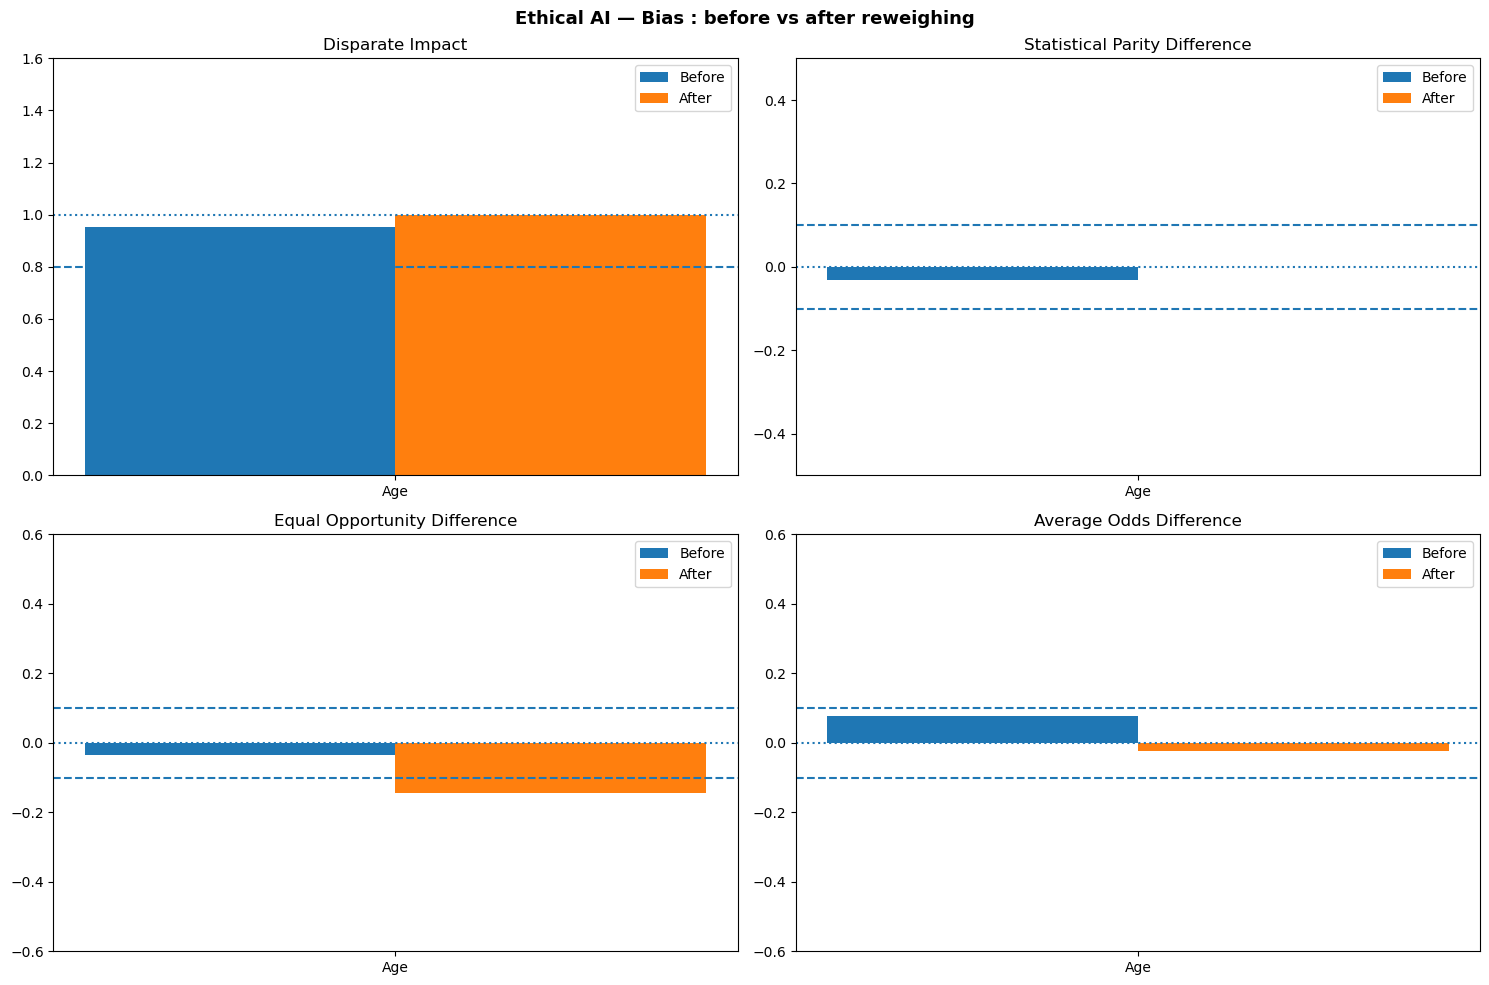

In [41]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Ethical AI — Bias : before vs after reweighing", fontsize=13, fontweight="bold")

metrics = [
    ("di", "Disparate Impact", 0, 1.6, 0.8, False),
    ("spd", "Statistical Parity Difference", -0.5, 0.5, 0.1, True),
    ("eod", "Equal Opportunity Difference", -0.6, 0.6, 0.1, True),
    ("aod", "Average Odds Difference", -0.6, 0.6, 0.1, True),
]

labels = ["Age"]
x = np.arange(len(results))
width = 0.35

for ax, (metric, title, ymin, ymax, threshold, centered) in zip(axes.flat, metrics):
    before = [r[f"{metric}_before"] for r in results]
    after = [r[f"{metric}_after"] for r in results]

    ax.bar(x - width/2, before, width, label="Before")
    ax.bar(x + width/2, after, width, label="After")

    if centered:
        ax.axhline(threshold, linestyle="--")
        ax.axhline(-threshold, linestyle="--")
        ax.axhline(0, linestyle=":")
    else:
        ax.axhline(threshold, linestyle="--")
        ax.axhline(1.0, linestyle=":")

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(ymin, ymax)
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Metric Reference

| Metric | What it measures | Fair threshold |
|---|---|---|
| **Disparate Impact (DI)** | Ratio of unfavorable outcome rates between groups. DI = P(terminated \| unprivileged) / P(terminated \| privileged) | ≥ 0.8 |
| **Statistical Parity Diff (SPD)** | Absolute gap in termination rates between groups | \|x\| < 0.1 |
| **Equal Opportunity Diff (EOD)** | Is the model equally good at catching actual leavers across groups? | \|x\| < 0.1 |
| **Average Odds Diff (AOD)** | Combines true positive AND false positive rate parity | \|x\| < 0.1 |

**Reweighing** assigns higher training weights to underrepresented groups so the model learns equally balanced patterns 